In [1]:
pip install -U langchain langchain-experimental langchain-groq pandas tabulate

  Using cached langchain_experimental-0.4.1-py3-none-any.whl.metadata (1.3 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
Using cached langchain_experimental-0.4.1-py3-none-any.whl (210 kB)
Using cached langchain_community-0.4.1-py3-none-any.whl (2.5 MB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 818.6 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.7 MB 998.8 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.7 MB 998.8 kB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.7 MB 743.7 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.7 MB 743.7 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.7 MB 743.7 kB/s eta 0:00:12
   ----- ----------------------------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.


##  | Library                    | Purpose                             
    | -------------------------- | -------------------------------------- |
    | **langchain**              | Build LLM applications                 |
    | **langchain-experimental** | New & research features of LangChain   |
    | **langchain-groq**         | Connect Groq LLMs to LangChain         |
    | **pandas**                 | Data analysis & manipulation           |
    | **tabulate**               | Beautiful table formatting in terminal |


In [3]:
import os
import getpass
import pandas as pd
from langchain_groq import ChatGroq
from langchain_experimental.agents import create_csv_agent

In [4]:
os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key:  ········


In [6]:
CSV_PATH = r"E:\Credit Score\credit_data.csv"   # replace with your file
df = pd.read_csv(r"E:\Credit Score\credit_data.csv")

print(df.head()) 

   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  


In [7]:
from langchain_groq import ChatGroq

groq_chat = ChatGroq(
    model="llama-3.3-70b-versatile",  # ✅ NEW MODEL
    temperature=0
)

## ✅ 1. verbose=True

Meaning:
This enables detailed logs during execution.

Why use it:
You want to see:

What the LLM is doing
| Step-by-step operations
| Tool calls
| Intermediate prompts
| Debug information

## ✅ 2. allow_dangerous_code=True

Meaning:
This allows the agent (or tool) to run unsafe Python code, such as:
| Writing files
| Deleting files
| Running subprocesses
| System-level commands
| Arbitrary Python execution

In [9]:
agent = create_csv_agent(
    llm=groq_chat,
    path=CSV_PATH,
    verbose=True,
    allow_dangerous_code=True
)

In [10]:
agent.invoke("How many rows and columns are in this dataset?")



> Entering new AgentExecutor chain...
Thought: To find the number of rows and columns in the dataset, I can use the `shape` attribute of the pandas DataFrame.

Action: python_repl_ast
Action Input: print(df.shape)(1000, 10)
I now know the final answer

Final Answer: The dataset contains 1000 rows and 10 columns.

> Finished chain.


{'input': 'How many rows and columns are in this dataset?',
 'output': 'The dataset contains 1000 rows and 10 columns.'}

In [12]:
agent.invoke("How are you bro")



> Entering new AgentExecutor chain...
Thought: The question "How are you bro" is not related to the pandas dataframe or any specific task, it seems to be a casual greeting. 

Action: None, as this is not a task-related question.

Thought: I should still respond in a friendly manner, but the question does not require any specific action or calculation.

Final Answer: I'm doing well, thanks for asking.

> Finished chain.


{'input': 'How are you bro', 'output': "I'm doing well, thanks for asking."}



> Entering new AgentExecutor chain...
Thought: To generate a pie chart for the 'Credit amount' and 'Duration' columns, we first need to calculate the total of each column.

Action: python_repl_ast
Action Input:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the total of each column
credit_total = df['Credit amount'].sum()
duration_total = df['Duration'].sum()

print("Credit Total: ", credit_total)
print("Duration Total: ", duration_total)
```
Credit Total:  3271258
Duration Total:  20903
Now that we have the total of each column, we can generate the pie chart. However, a pie chart is typically used to show the proportion of different categories in a dataset. Since 'Credit amount' and 'Duration' are numerical columns, we might want to consider a different type of chart, such as a bar chart or a histogram, to visualize the distribution of these columns. But if we still want to create a pie chart, we can use the total values as the size of the slices.

Action

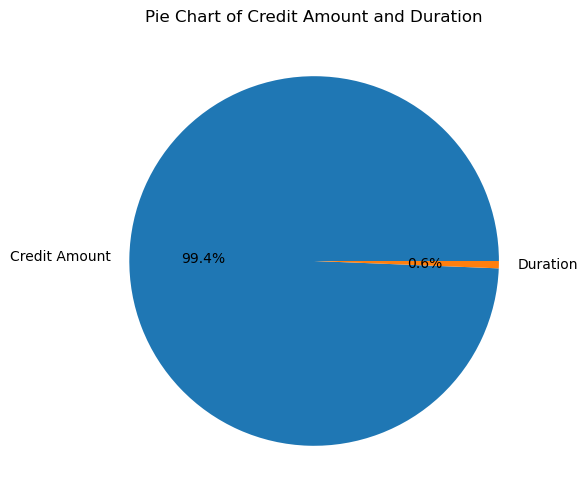

I now know the final answer

Final Answer: The pie chart for the 'Credit amount' and 'Duration' columns can be generated using the following code:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the total of each column
credit_total = df['Credit amount'].sum()
duration_total = df['Duration'].sum()

# Create a pie chart
plt.figure(figsize=(8,6))
plt.pie([credit_total, duration_total], labels=['Credit Amount', 'Duration'], autopct='%1.1f%%')
plt.title('Pie Chart of Credit Amount and Duration')
plt.show()
```
This code will create a pie chart with two slices, one for 'Credit Amount' and one for 'Duration', with the size of each slice proportional to the total value of each column. The `autopct` parameter is used to display the percentage value of each slice.

> Finished chain.


{'input': 'genrate the pie chart for columns Credit amount, Duration columns',
 'output': "The pie chart for the 'Credit amount' and 'Duration' columns can be generated using the following code:\n```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Calculate the total of each column\ncredit_total = df['Credit amount'].sum()\nduration_total = df['Duration'].sum()\n\n# Create a pie chart\nplt.figure(figsize=(8,6))\nplt.pie([credit_total, duration_total], labels=['Credit Amount', 'Duration'], autopct='%1.1f%%')\nplt.title('Pie Chart of Credit Amount and Duration')\nplt.show()\n```\nThis code will create a pie chart with two slices, one for 'Credit Amount' and one for 'Duration', with the size of each slice proportional to the total value of each column. The `autopct` parameter is used to display the percentage value of each slice."}

In [13]:
agent.invoke("genrate the pie chart for columns Credit amount, Duration columns")



> Entering new AgentExecutor chain...
Thought: To generate a line chart for the 'Credit amount' and 'Duration' columns, I need to use a library that can create visualizations, such as matplotlib. I will import the necessary libraries and then use the plot function to create the line chart.

Action: python_repl_ast
Action Input:
```python
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(df['Credit amount'], label='Credit amount')
plt.plot(df['Duration'], label='Duration')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Line Chart for Credit amount and Duration')
plt.legend()
plt.show()
```

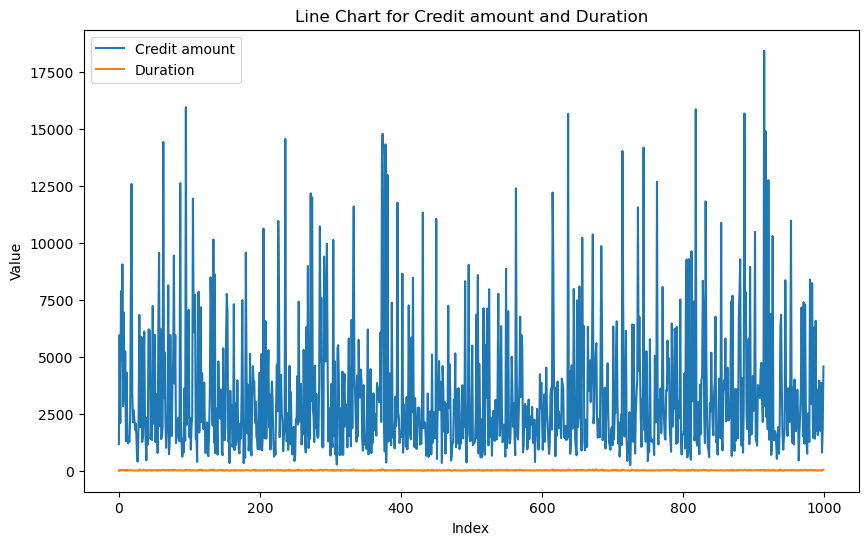

I now know the final answer

The code provided will generate a line chart with the 'Credit amount' and 'Duration' columns. The x-axis represents the index of the dataframe, and the y-axis represents the values in the 'Credit amount' and 'Duration' columns. The chart will have a title, labels for the x and y axes, and a legend to distinguish between the two lines.

Final Answer: The line chart for the 'Credit amount' and 'Duration' columns can be generated using the provided code.

> Finished chain.


{'input': 'genrate the line chart for columns Credit amount, Duration columns',
 'output': "The line chart for the 'Credit amount' and 'Duration' columns can be generated using the provided code."}

In [14]:
agent.invoke("genrate the line chart for columns Credit amount, Duration columns")



> Entering new AgentExecutor chain...
Thought: To generate the pie chart, line chart, and bar graph for the Credit_data, we first need to understand what Credit_data is. Since we are working with a pandas dataframe `df`, we can assume that Credit_data refers to the 'Credit amount' column in the dataframe.

Action: python_repl_ast
Action Input: 
```python
import matplotlib.pyplot as plt

# Get the 'Credit amount' column
credit_amount = df['Credit amount']

# Print the credit amount to understand its distribution
print(credit_amount)
```
0      1169
1      5951
2      2096
3      7882
4      4870
       ... 
995    1736
996    3857
997     804
998    1845
999    4576
Name: Credit amount, Length: 1000, dtype: int64
To generate the pie chart, line chart, and bar graph for the Credit_data, we need to decide what these charts will represent. 

For a pie chart, it would make sense to show the distribution of credit amounts across different ranges or categories. 

For a line chart, we could 

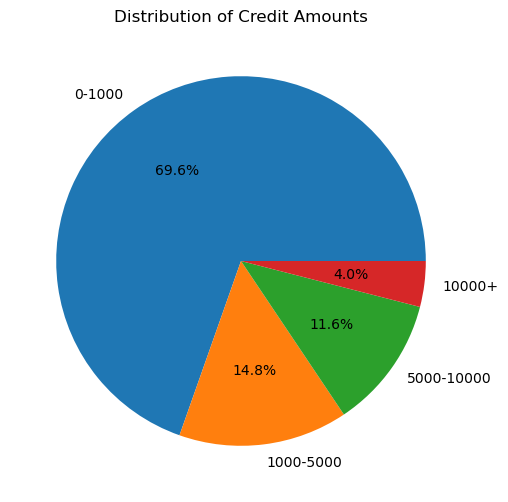

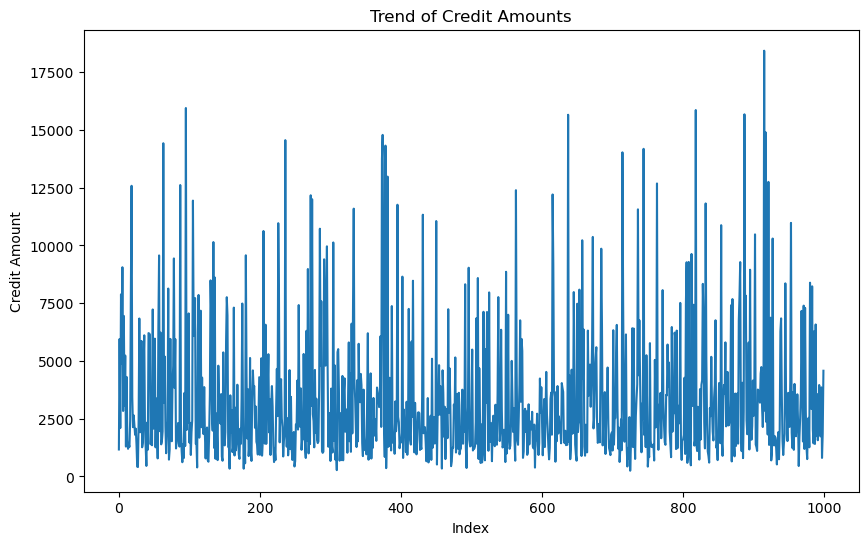

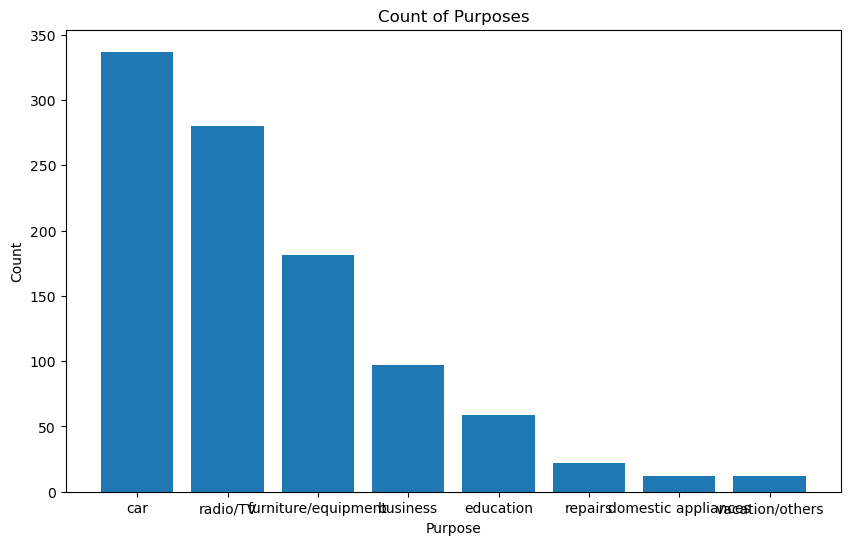

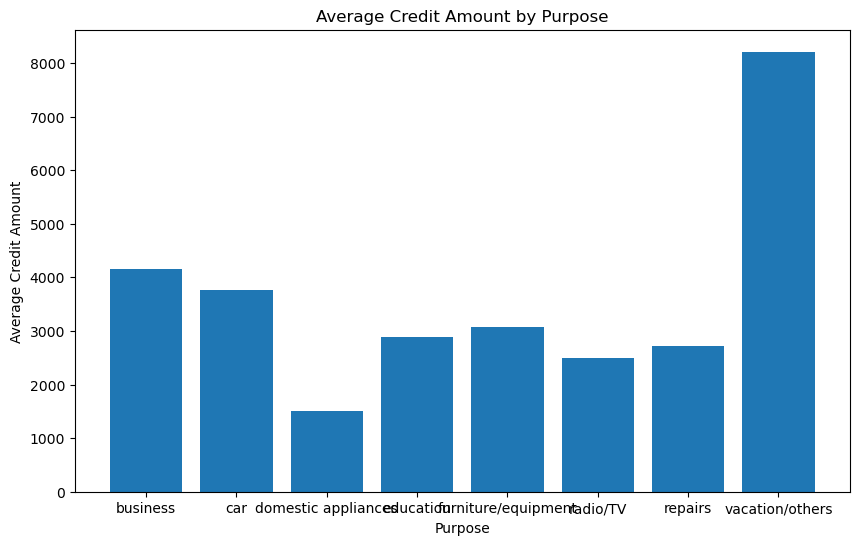

I now know the final answer

The code provided generates four different plots:

1. A pie chart showing the distribution of credit amounts across different ranges (0-1000, 1000-5000, 5000-10000, 10000+).
2. A line chart showing the trend of credit amounts over time (or across different indices).
3. A bar graph showing the count of different purposes.
4. A bar graph showing the average credit amount by purpose.

These plots provide insights into the distribution and trends of credit amounts in the dataset.

Final Answer: The provided code generates a pie chart, line chart, and two bar graphs for the Credit_data, providing insights into the distribution and trends of credit amounts in the dataset.

> Finished chain.


{'input': 'genrate the pie chart, line chart and bar graph for the Creadit_data',
 'output': 'The provided code generates a pie chart, line chart, and two bar graphs for the Credit_data, providing insights into the distribution and trends of credit amounts in the dataset.'}

In [15]:
agent.invoke("genrate the pie chart, line chart and bar graph for the Creadit_data")



> Entering new AgentExecutor chain...
Thought: To analyze the data and create a dashboard with a pie chart and bar graph, I first need to understand the structure and content of the dataframe. The dataframe `df` seems to contain various columns such as `Age`, `Sex`, `Job`, `Housing`, `Saving accounts`, `Checking account`, `Credit amount`, `Duration`, and `Purpose`. 

Action: python_repl_ast
Action Input: print(df.info())<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Dur

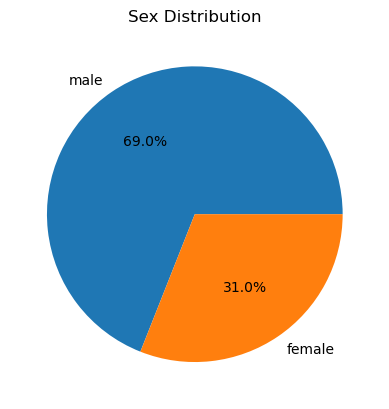

The code provided creates a pie chart to visualize the distribution of the 'Sex' column in the dataframe. 

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df['Job'].value_counts().plot(kind='bar'); plt.title('Job Distribution'); plt.show()

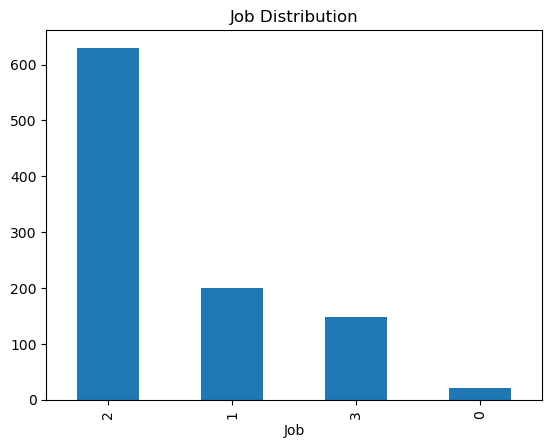

The code provided creates a bar graph to visualize the distribution of the 'Job' column in the dataframe.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df['Purpose'].value_counts().plot(kind='bar'); plt.title('Purpose Distribution'); plt.show()

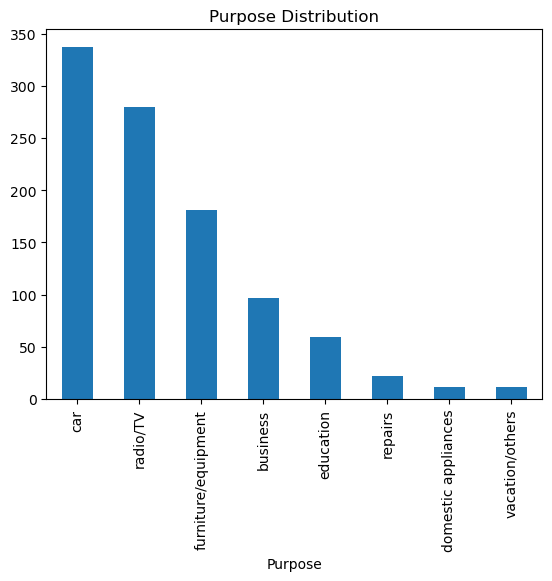

The code provided creates a bar graph to visualize the distribution of the 'Purpose' column in the dataframe.

Thought: I now know the final answer

Final Answer: To analyze the data and create a dashboard with a pie chart and bar graph, you can use the following code:

```python
import matplotlib.pyplot as plt

# Create a pie chart for the 'Sex' column
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sex Distribution')
plt.show()

# Create a bar graph for the 'Job' column
df['Job'].value_counts().plot(kind='bar')
plt.title('Job Distribution')
plt.show()

# Create a bar graph for the 'Purpose' column
df['Purpose'].value_counts().plot(kind='bar')
plt.title('Purpose Distribution')
plt.show()
```

This code will create three separate plots: a pie chart for the 'Sex' column, and two bar graphs for the 'Job' and 'Purpose' columns. Each plot will display the distribution of the respective column in the dataframe.

> Finished chain.


{'input': 'analyse the data and make the dashboard using pie chart and bar graph',
 'output': "To analyze the data and create a dashboard with a pie chart and bar graph, you can use the following code:\n\n```python\nimport matplotlib.pyplot as plt\n\n# Create a pie chart for the 'Sex' column\ndf['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')\nplt.title('Sex Distribution')\nplt.show()\n\n# Create a bar graph for the 'Job' column\ndf['Job'].value_counts().plot(kind='bar')\nplt.title('Job Distribution')\nplt.show()\n\n# Create a bar graph for the 'Purpose' column\ndf['Purpose'].value_counts().plot(kind='bar')\nplt.title('Purpose Distribution')\nplt.show()\n```\n\nThis code will create three separate plots: a pie chart for the 'Sex' column, and two bar graphs for the 'Job' and 'Purpose' columns. Each plot will display the distribution of the respective column in the dataframe."}

In [16]:
agent.invoke("analyse the data and make the dashboard using pie chart and bar graph")

In [17]:
import os 